# Simulating Visium-like data (spot-resolution)

This notebook reproduces the **exact configuration** used to validate
`albis`'s Visium-like, spot-resolution output against real Visium data in
the manuscript's Figure 2 (the `spot_vs_lymph_node_visium` /
`spot_vs_tonsil_visium` count-distribution comparisons, compared against two
18k-gene CytAssist FFPE probe-based references).

Same low-level API as `lower_level_api_tutorial.ipynb` and the Xenium
tutorial in this folder -- `theta`/`theta_jitter`/`base_gene_lognormal`/
`batch_sigma` all need tuning away from defaults, which `generate_data()`
does not expose.

## Setup

Install Albis, including plotting support, in your Python environment:

```bash
pip install albis
```

Download this notebook and open it in Jupyter using the same environment.
If Jupyter is not already installed:

```bash
pip install notebook
jupyter notebook
```

If you are already in a notebook, run `%pip install albis` in a cell to
install into the active kernel, then restart the kernel if needed.


In [1]:
from pathlib import Path

import albis as ab
import numpy as np

print("Albis version:", ab.__version__)


Albis version: 0.1.2


## The exact Figure 2 "spot" configuration

The domain/tissue-shape block is identical across all four Figure 2
configurations (cell, spot, and both VisiumHD bin sizes) -- only the
expression-noise knobs, `sphere_R_um`, and the platform-specific
`spot_spacing_um`/`spot_radius_um` capture geometry differ. `sphere_R_um=2050`
(well below the simulator's 6000um default) raises the 3D cell-packing
fraction: at the default packing, a fixed spot/bin grid mostly lands in
empty interstitial space (see the `core_fuzz_width_um` /
`max_shift` comments below -- both scale with `sphere_R_um`, so they change
too).

In [2]:
sphere_r_um = 2050.0          # TUNED: raises 3D packing fraction so spots aren't mostly empty

config = {
    # ==== 3D tissue geometry and cell placement ====
    "sphere_R_um": sphere_r_um,
    "center": (0.0, 0.0, 0.0),                 # default
    "n_cells": 600_000,                        # manuscript scale
    "allow_cell_overlap": False,               # default
    "cell_radius_kwargs": dict(                # manuscript default (not overridden for spot)
        radius_dist="lognormal", r_mean=7.5, r_sigma=0.28, r_min=4.0, r_max=14.0,
    ),

    # ==== Spatial domains with irregular boundaries (manuscript-wide, all 4 pairings) ====
    "n_domains": 6,
    "core_frac": 0.55,
    "core_bump_amp": 0.25,
    "wedge_angle_amp_deg": 25.0,
    "noise_terms": 16,
    "noise_freq_range": (3.0, 6.0),
    "boundary_fuzz_width_deg": 6.0,
    "boundary_fuzz_flip_prob": 0.15,
    "core_fuzz_width_um": 0.05 * sphere_r_um,  # manuscript ratio: scales with sphere_R_um
    "core_fuzz_flip_prob": 0.25,

    # ==== Cell type composition by domain ====
    "n_cell_types": 8,
    "domain_type_mix": None,   # filled in below (manuscript_domain_type_mix)

    # ==== Gene programs and per-cell gene expression ====
    "marker_genes_per_type": 80,               # default
    "noise_gene_frac": 0.10,                   # default
    "shared_marker_frac": 0.25,                # default
    "base_gene_lognormal": (-2.25, 1.0),       # TUNED: lower counts and wider gene-to-gene spread vs. default (0.7, 0.7)
    "marker_foldchange": 3.5,                  # default
    "shared_marker_foldchange": 2.5,           # default
    "noise_scale": 1.3,                        # TUNED: manuscript "noisy" baseline (default 0.9)
    "cell_size_lognormal": (0.0, 0.35),        # default
    "domain_size_factors": None,               # default (no per-domain expression shift)
    "theta": 0.25,                             # TUNED: NB dispersion, picked against 2 real CytAssist probe refs
    "theta_jitter": 0.10,                      # TUNED: per-gene spread of theta -- see note below

    # ==== Transcript-level molecule simulation ====
    "inside_prob": 0.95,                       # default
    "assign_k": 8,                             # default

    # ==== Platform-specific capture windows ====
    "xenium_capture_window_um": (12000.0, 24000.0),  # unused for spot output
    "capture_window_um": (6500.0, 6500.0),           # real Visium slide window (6.5x6.5mm) -- crops spot output
    "capture_window_center_um": (0.0, 0.0),          # default
    "bin_size_um": 8.0,                              # unused for spot output
    "spot_spacing_um": 100.0,                        # default -- Visium spot center-to-center spacing
    "spot_radius_um": 27.5,                          # default -- Visium spot capture radius

    # ==== Slicing, batch effects, and unaligned coordinates ====
    "n_slices": 10,
    "slice_axes": ("Z",),
    "batch_sigma": 0.3,                        # TUNED: per-slice technical batch effect
    "max_deg": 270.0,
    "max_shift": 0.5 * sphere_r_um,            # manuscript ratio: scales with sphere_R_um
    "base_seed_unaligned": 12345,              # default
    "sync_unaligned_seed": True,               # same per-slice misalignment across cell/bin/spot

    # ==== Simulation outputs ====
    "output_modalities": ("spot",),            # spot-resolution aggregation -- the defining choice for "Visium-like"
    "sparse_X": True,                          # default
    "seed": 2025,                              # default
}


In [3]:
# Manuscript-baseline domain_type_mix (6 domains x 8 cell types). Every domain
# gets a distinct, non-uniform composition -- this is what Figure 2/3's
# domain_true and cell_type_true ground truth is built on. (An alternative
# "strong" mix with much sharper per-domain enrichment exists for dedicated
# domain-recovery test runs, but every Figure 2 count-distribution config uses
# this manuscript-baseline matrix.)
manuscript_domain_type_mix = np.array([
    [0.18, 0.18, 0.13, 0.12, 0.11, 0.10, 0.09, 0.09],
    [0.11, 0.12, 0.18, 0.18, 0.13, 0.10, 0.09, 0.09],
    [0.10, 0.11, 0.12, 0.13, 0.18, 0.18, 0.09, 0.09],
    [0.10, 0.10, 0.11, 0.12, 0.13, 0.13, 0.16, 0.15],
    [0.14, 0.13, 0.12, 0.11, 0.12, 0.13, 0.13, 0.12],
    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
])
config["domain_type_mix"] = manuscript_domain_type_mix


> **Note on `theta_jitter`.** Per-gene NB dispersion is drawn
> `~Normal(theta, theta_jitter)` and floored at a small positive value if the
> draw goes non-positive. With `theta=0.25`, a jitter of `1.0` (the
> function's own default) floors roughly 40% of genes into extreme
> overdispersion -- visible as two disjoint clouds in a mean-variance plot.
> `0.10` was the largest jitter found to fully collapse that back into one
> continuous, realistic per-gene scatter. If you change `theta` here, re-check
> whether `theta_jitter` still needs adjusting alongside it.

> **Runtime warning.** This notebook reproduces the manuscript's actual
> Figure 2 configuration at full scale (**600,000 cells**), not a reduced
> interactive-scale example like `higher_level_api_tutorial.ipynb` /
> `lower_level_api_tutorial.ipynb`. All 600,000 cells are simulated at full 3D tissue scale before being aggregated down to spots, so generation is slow even though the final spot-level output has few observations. If you just want to see the
> API work end-to-end quickly, drop `n_cells` and `sphere_R_um` down (e.g.
> `n_cells=5000`, proportionally smaller `sphere_R_um`) -- every other
> parameter below is still the exact manuscript value.


## Generate

In [4]:
sim = ab.simulate_3d_molecule_sphere_multires(**config)

print("top-level keys:", list(sim.keys()))
adata = sim["spot_adatas"]["Z"]
adata


top-level keys: ['adata_cell_true', 'adata_cell_obs', 'adata_cell_sectioned', 'bin_adatas', 'spot_adatas', 'meta']


AnnData object with n_obs × n_vars = 43560 × 556
    obs: 'slice_axis', 'slice_id', 'spot_spacing_um', 'spot_radius_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

## Inspect the output

In [5]:
print(adata)
print()
print("n_obs (observations):", adata.n_obs)
print("n_vars (genes):", adata.n_vars)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))


AnnData object with n_obs × n_vars = 43560 × 556
    obs: 'slice_axis', 'slice_id', 'spot_spacing_um', 'spot_radius_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

n_obs (observations): 43560
n_vars (genes): 556
obs columns: ['slice_axis', 'slice_id', 'spot_spacing_um', 'spot_radius_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty']
var columns: ['gene_class', 'is_noise', 'is_shared_marker']


In [6]:
summary = ab.describe(adata)
summary


{'n_obs': 43560,
 'n_vars': 556,
 'total_counts': 22680543,
 'nonzero_counts': 3365512,
 'platform': None,
 'slice_axis': None,
 'n_slices': 10,
 'slice_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'obs_columns': ['slice_axis',
  'slice_id',
  'spot_spacing_um',
  'spot_radius_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true',
  'is_empty'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors', 'rigid_perturb_inplane'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

### Empirical count dispersion

`generate_simulation_noisy.py` (the manuscript script this notebook mirrors)
fits an empirical per-gene NB dispersion from the pre-batch counts as a sanity
check against real platform data via
`sim_paper/code/count_distribution/count_distribution.py --compare-input`.
Same check here:

In [7]:
def fit_empirical_theta(X):
    """Same method count_distribution.py uses to fit an empirical NB dispersion
    from a count matrix, for comparing against real platform data."""
    if hasattr(X, "multiply"):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        mean_sq = (X ** 2).mean(axis=0)
    var = mean_sq - mean ** 2
    overdispersed = var > mean
    theta_hat = mean[overdispersed] ** 2 / (var[overdispersed] - mean[overdispersed])
    theta_hat = theta_hat[np.isfinite(theta_hat) & (theta_hat > 0)]
    return float(np.median(theta_hat)) if theta_hat.size else float("nan")

raw_counts = adata.layers["counts_pre_batch"] if "counts_pre_batch" in adata.layers else adata.X
empirical_theta = fit_empirical_theta(raw_counts)
print(f"empirical theta_hat = {empirical_theta:.3f}")


empirical theta_hat = 0.175


## Plot

`ab.plot()` returns a Matplotlib figure. `coordinates="aligned"` shows the
canonical tissue coordinates (what `domain_true`/`cell_type_true` were
assigned against); `coordinates="unaligned"` shows the per-slice rigid
misalignment `max_deg`/`max_shift` introduce -- the same synthetic
registration-error ground truth used elsewhere in the manuscript.

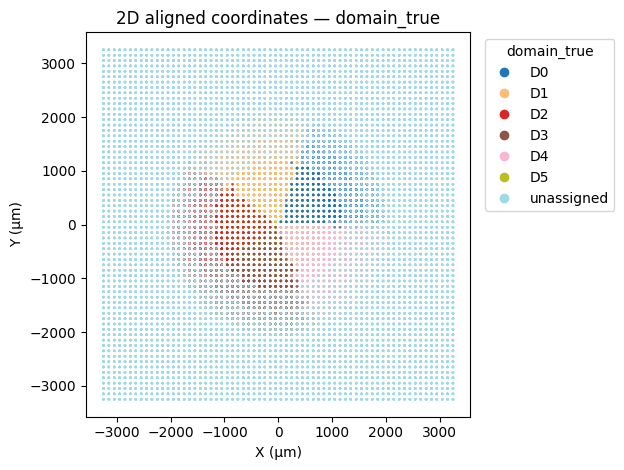

In [8]:
fig = ab.plot(adata, view="2d", coordinates="aligned", color="domain_true", point_size=3)


### Drop empty spots (QC)

The spot grid tiles the whole 6.5 × 6.5 mm capture window, so spots outside the
tissue capture nothing: they are flagged `obs["is_empty"]` and labelled `unassigned`
above. Dropping them keeps only the tissue. (The manuscript's QC additionally
requires at least 3 detected genes per observation.)

43,560 spots -> 10,062 after dropping empty spots


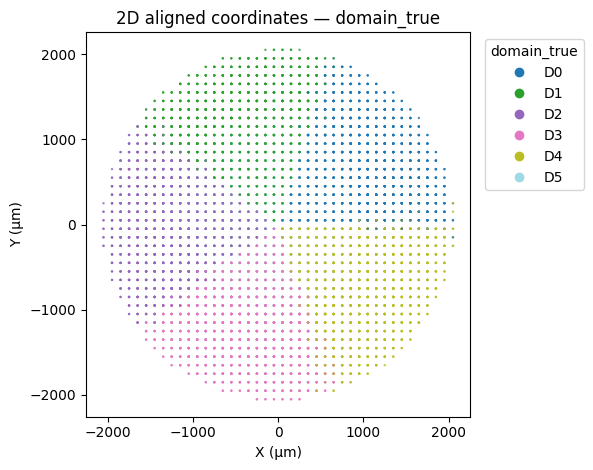

In [9]:
adata_qc = adata[~adata.obs["is_empty"]].copy()
print(f"{adata.n_obs:,} spots -> {adata_qc.n_obs:,} after dropping empty spots")
fig = ab.plot(adata_qc, view="2d", coordinates="aligned", color="domain_true", point_size=3)

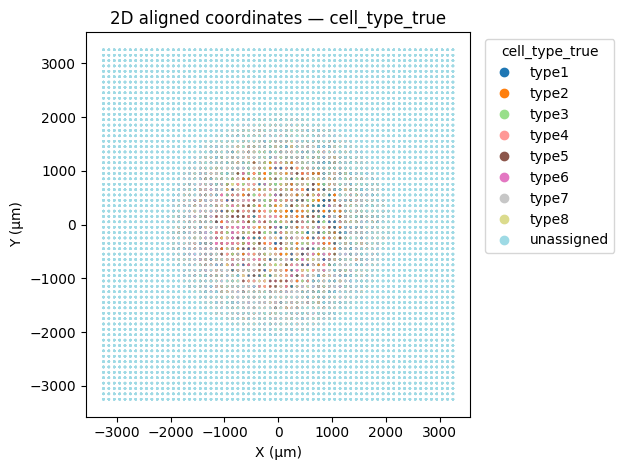

In [10]:
fig = ab.plot(adata, view="2d", coordinates="aligned", color="cell_type_true", point_size=3)


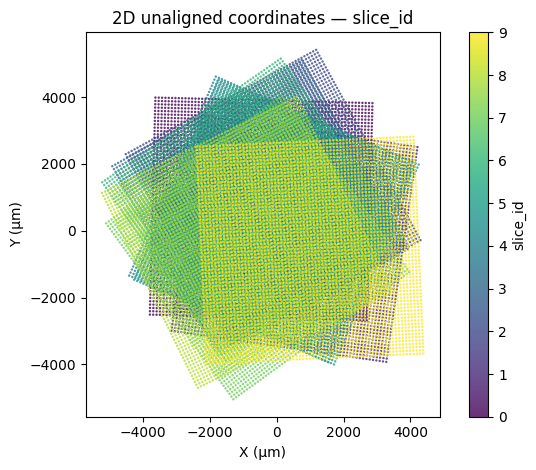

In [11]:
fig = ab.plot(adata, view="2d", coordinates="unaligned", color="slice_id", point_size=3)


## Save

Same `ab.save(...)` helper as the other two tutorials -- writes an `AnnData`
to `.h5ad` and returns the path.

In [12]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_path = ab.save(adata, output_dir / "visium_spot_z.h5ad")
output_path


PosixPath('outputs/visium_spot_z.h5ad')